# Telecom Billing and Revenue Assurance — Exploratory Analysis

This notebook analyses billing, collections, customer risk and revenue leakage using the PostgreSQL analytics views.

In [9]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import URL, create_engine, text

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
IMAGE_DIRECTORY = PROJECT_ROOT / 'images'
IMAGE_DIRECTORY.mkdir(parents=True, exist_ok=True)
load_dotenv(PROJECT_ROOT / '.env')

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['axes.titleweight'] = 'bold'
pd.options.display.float_format = '{:,.2f}'.format

## 1. Connect to PostgreSQL

In [10]:
database_url = URL.create(
    'postgresql+psycopg',
    username=os.getenv('DB_USER'),
    password=os.getenv('DB_PASSWORD'),
    host=os.getenv('DB_HOST'),
    port=int(os.getenv('DB_PORT', '5432')),
    database=os.getenv('DB_NAME'),
)
engine = create_engine(database_url)

with engine.connect() as connection:
    database_name = connection.execute(text('SELECT current_database()')).scalar_one()
print(f'Connected to: {database_name}')

Connected to: telecom_revenue_analytics


## 2. Load aggregated analytical datasets

In [11]:
monthly = pd.read_sql(
    '''
    SELECT
        revenue_month,
        SUM(invoice_count) AS invoice_count,
        SUM(total_billed) AS total_billed,
        SUM(net_collected) AS net_collected,
        SUM(outstanding_balance) AS outstanding_balance
    FROM vw_monthly_kpis
    GROUP BY revenue_month
    ORDER BY revenue_month
    ''',
    engine,
)

segment_product = pd.read_sql(
    '''
    SELECT
        customer_segment,
        product_type,
        SUM(invoice_count) AS invoice_count,
        SUM(total_billed) AS total_billed,
        SUM(net_collected) AS net_collected,
        SUM(outstanding_balance) AS outstanding_balance,
        ROUND(100.0 * SUM(net_collected)
              / NULLIF(SUM(total_billed + net_adjustments), 0), 2)
            AS collection_rate_pct
    FROM vw_monthly_kpis
    GROUP BY customer_segment, product_type
    ORDER BY customer_segment, product_type
    ''',
    engine,
)

leakage = pd.read_sql(
    '''
    SELECT
        leakage_type,
        COUNT(*) AS leakage_cases,
        SUM(total_estimated_leakage) AS estimated_leakage
    FROM vw_revenue_leakage
    GROUP BY leakage_type
    ORDER BY estimated_leakage DESC
    ''',
    engine,
)

risk = pd.read_sql(
    '''
    SELECT
        risk_level,
        COUNT(*) AS customers,
        SUM(outstanding_balance) AS outstanding_balance
    FROM vw_customer_risk
    GROUP BY risk_level
    ORDER BY CASE risk_level
        WHEN 'High' THEN 1 WHEN 'Medium' THEN 2 ELSE 3 END
    ''',
    engine,
)

print('Monthly rows:', len(monthly))
display(segment_product)
display(leakage)
display(risk)

Monthly rows: 24


,customer_segment,product_type,invoice_count,total_billed,net_collected,outstanding_balance,collection_rate_pct
0,Enterprise,Broadband,"19,317.00","2,308,342.01","1,917,349.65","325,997.24",83.33
1,Enterprise,Mobile,"18,653.00","1,775,551.58","1,488,453.58","238,669.34",84.14
2,Residential,Broadband,"179,577.00","16,710,908.29","13,893,183.14","2,325,587.53",83.40
3,Residential,Mobile,"177,984.00","12,679,708.88","10,564,540.37","1,749,549.94",83.58
4,Small Business,Broadband,"49,499.00","5,604,242.84","4,676,721.99","764,870.62",83.73
5,Small Business,Mobile,"65,565.00","5,680,965.72","4,737,455.19","785,339.71",83.65


,leakage_type,leakage_cases,estimated_leakage
0,Base Charge Underbilling,7402,"157,393.40"
1,Usage Charge Underbilling,8298,"114,169.90"
2,Base and Usage Underbilling,122,"3,902.04"


,risk_level,customers,outstanding_balance
0,High,8836,"3,987,572.87"
1,Medium,9838,"1,874,566.77"
2,Low,6057,"327,874.74"


## 3. Executive KPI summary

In [12]:
kpis = pd.read_sql(
    '''
    SELECT
        COUNT(*) AS invoice_count,
        SUM(total_amount) AS total_billed,
        SUM(net_payment) AS net_collected,
        SUM(outstanding_balance) AS collectible_outstanding,
        100.0 * SUM(net_payment)
            / NULLIF(SUM(adjusted_invoice_amount), 0) AS collection_rate_pct
    FROM vw_invoice_financials
    ''',
    engine,
)
kpis['detected_leakage'] = leakage['estimated_leakage'].sum()
display(kpis.T.rename(columns={0: 'Value'}))

,Value
invoice_count,"510,595.00"
total_billed,"44,759,719.32"
net_collected,"37,277,703.92"
collectible_outstanding,"6,190,014.38"
collection_rate_pct,83.55
detected_leakage,"275,465.34"


## 4. Monthly billing and collections trend

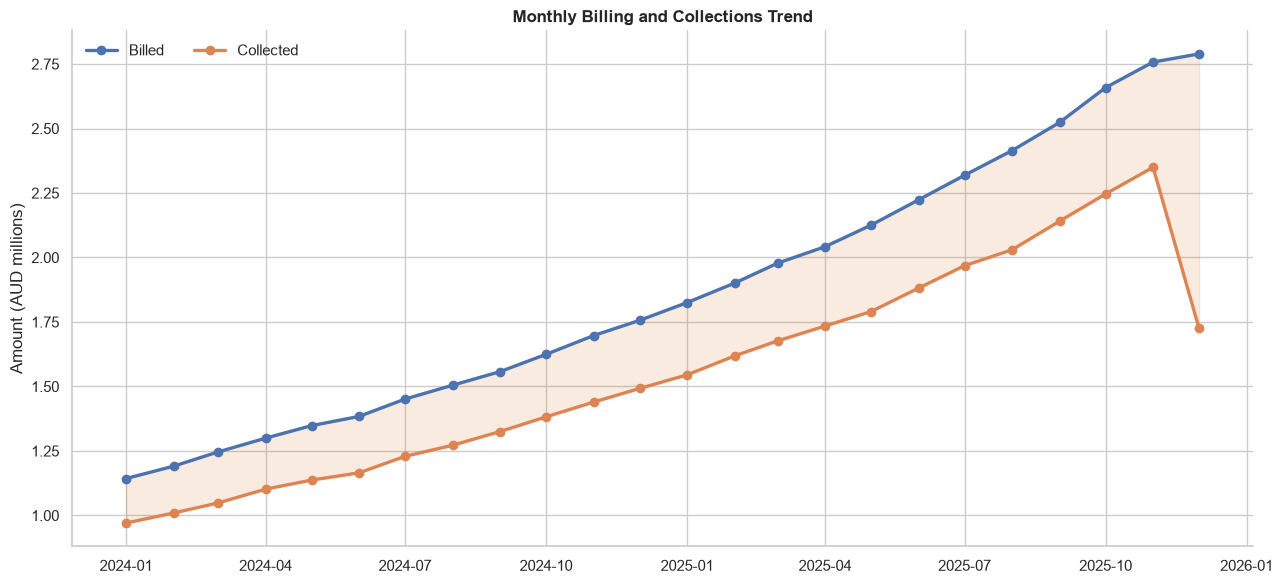

In [13]:
monthly['revenue_month'] = pd.to_datetime(monthly['revenue_month'])
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(monthly['revenue_month'], monthly['total_billed'] / 1_000_000,
        marker='o', linewidth=2.4, label='Billed')
ax.plot(monthly['revenue_month'], monthly['net_collected'] / 1_000_000,
        marker='o', linewidth=2.4, label='Collected')
ax.fill_between(monthly['revenue_month'],
                monthly['net_collected'] / 1_000_000,
                monthly['total_billed'] / 1_000_000,
                alpha=0.12, color='#D55E00')
ax.set(title='Monthly Billing and Collections Trend',
       xlabel='', ylabel='Amount (AUD millions)')
ax.legend(frameon=False, ncol=2)
sns.despine()
fig.tight_layout()
fig.savefig(IMAGE_DIRECTORY / 'monthly billing and collections.png', dpi=200, bbox_inches='tight')
plt.show()

## 5. Revenue leakage profile

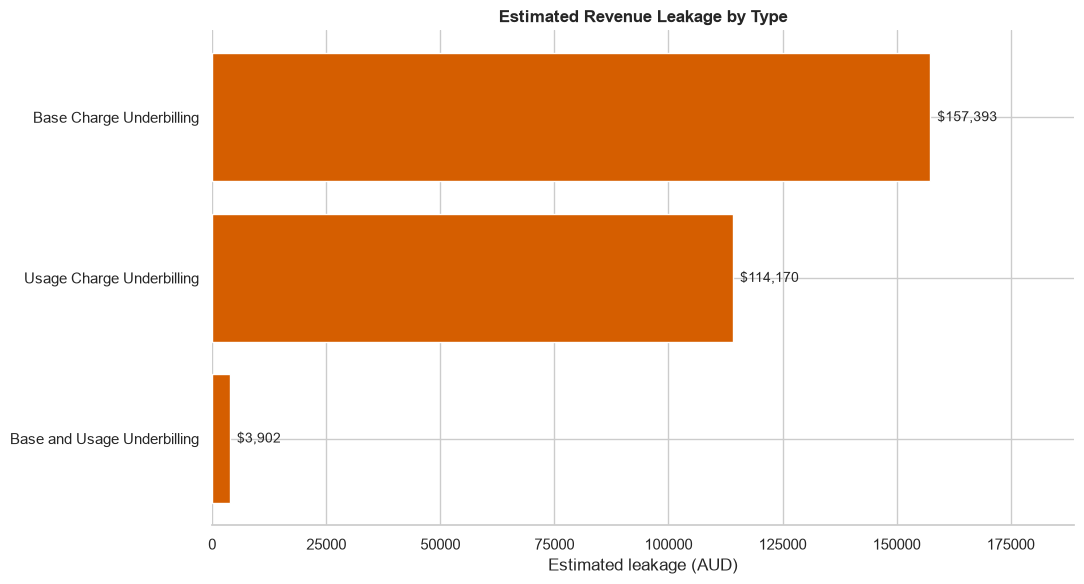

In [14]:
fig, ax = plt.subplots(figsize=(11, 6))
plot_data = leakage.sort_values('estimated_leakage', ascending=True)
bars = ax.barh(plot_data['leakage_type'],
               plot_data['estimated_leakage'], color='#D55E00')
ax.bar_label(bars, labels=[f'${value:,.0f}' for value in plot_data['estimated_leakage']],
             padding=5, fontsize=10)
ax.set(title='Estimated Revenue Leakage by Type', xlabel='Estimated leakage (AUD)', ylabel='')
ax.set_xlim(0, plot_data['estimated_leakage'].max() * 1.20)
sns.despine(left=True)
fig.tight_layout()
fig.savefig(IMAGE_DIRECTORY / 'revenue leakage by type.png', dpi=200, bbox_inches='tight')
plt.show()

## 6. Customer risk and outstanding balance

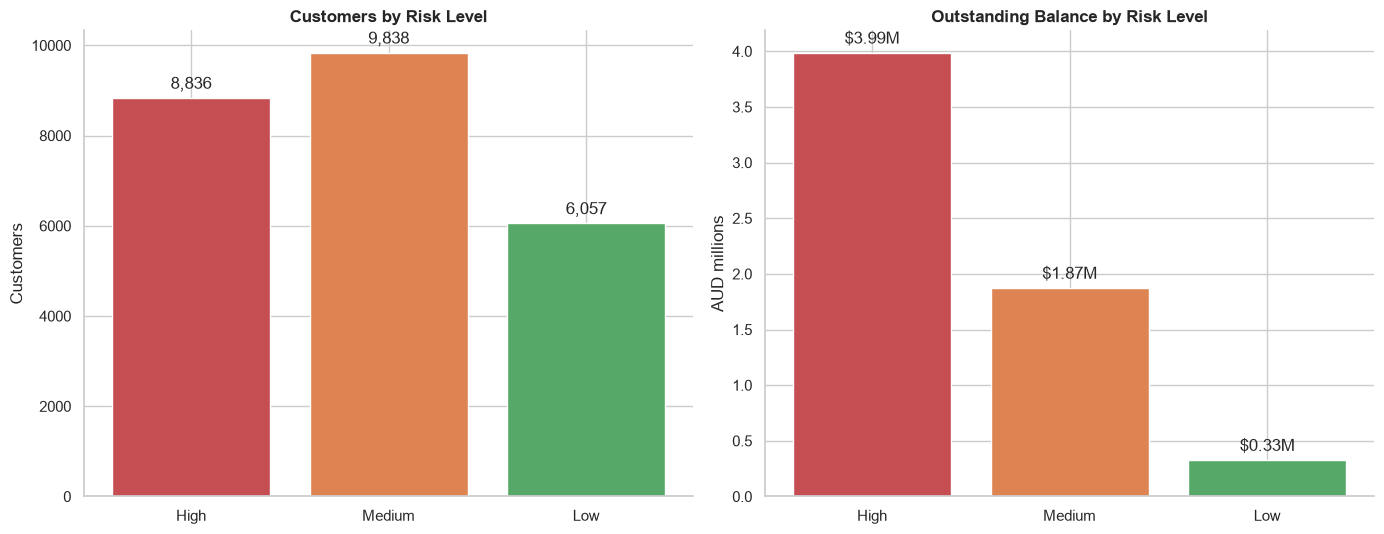

In [15]:
risk_order = ['High', 'Medium', 'Low']
risk_plot = risk.set_index('risk_level').reindex(risk_order).reset_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
colors = ['#C44E52', '#DD8452', '#55A868']

bars_1 = axes[0].bar(risk_plot['risk_level'], risk_plot['customers'], color=colors)
axes[0].bar_label(bars_1, labels=[f'{value:,.0f}' for value in risk_plot['customers']], padding=4)
axes[0].set(title='Customers by Risk Level', xlabel='', ylabel='Customers')

bars_2 = axes[1].bar(risk_plot['risk_level'], risk_plot['outstanding_balance'] / 1_000_000,
                     color=colors)
axes[1].bar_label(bars_2,
                  labels=[f'${value / 1_000_000:.2f}M' for value in risk_plot['outstanding_balance']],
                  padding=4)
axes[1].set(title='Outstanding Balance by Risk Level', xlabel='', ylabel='AUD millions')
sns.despine()
fig.tight_layout()
fig.savefig(IMAGE_DIRECTORY / 'customer risk profile.png', dpi=200, bbox_inches='tight')
plt.show()

## 7. Segment and product performance

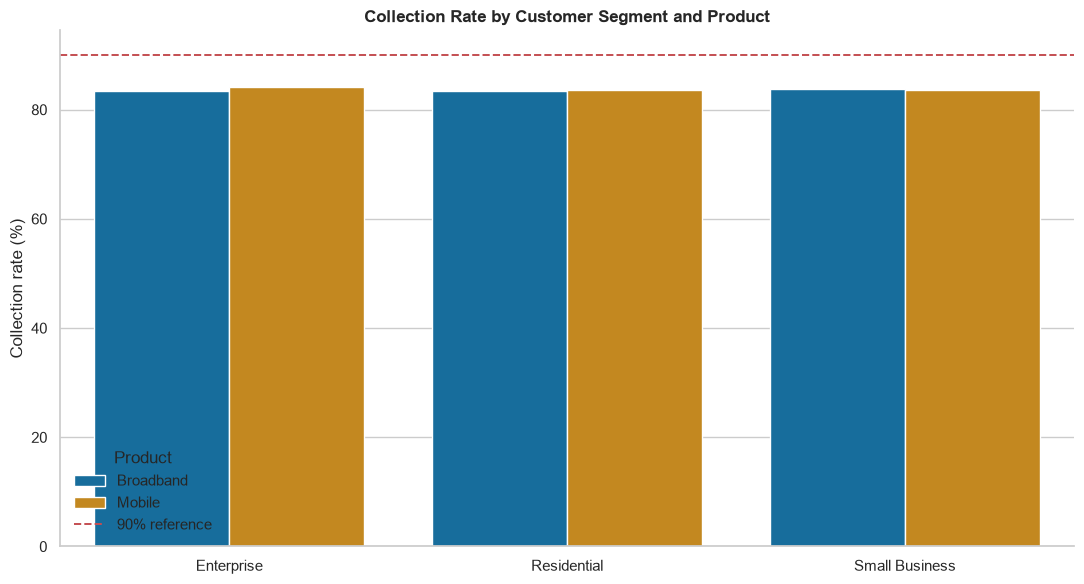

In [16]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=segment_product, x='customer_segment', y='collection_rate_pct',
            hue='product_type', palette='colorblind', ax=ax)
ax.axhline(90, color='#C44E52', linestyle='--', linewidth=1.4, label='90% reference')
ax.set(title='Collection Rate by Customer Segment and Product',
       xlabel='', ylabel='Collection rate (%)')
ax.legend(title='Product', frameon=False)
sns.despine()
fig.tight_layout()
fig.savefig(IMAGE_DIRECTORY / 'collection rate by segment and product.png',
            dpi=200, bbox_inches='tight')
plt.show()

## Initial findings

- The business generated $44.76 million in billed revenue and collected $37.28 million, producing an overall collection rate of 83.55%.
- Collectible outstanding balances total $6.19 million. High-risk customers represent 35.7% of assessed customers but account for approximately 64.4% of the outstanding balance, making them the primary collections priority.
- The analysis detected 15,822 invoices with potential revenue leakage worth approximately $275,465.
- Base-charge underbilling produced the largest identified leakage amount at $157,393, while usage-charge underbilling affected the greatest number of invoices.
- Collection rates are relatively consistent across customer segments and products, ranging from 83.33% to 84.14%. Enterprise Mobile achieved the highest rate, while Enterprise Broadband recorded the lowest.
- These findings indicate that the strongest immediate opportunities are targeted recovery from high-risk customers and automated controls for recurring and excess-usage charges.